In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
csv_path = Path("whether_data.csv")

if not csv_path.exists():
    csv_path = Path("whether-data-analysis-using-python") / "whether_data.csv"

df = pd.read_csv(csv_path)
df.head()

,Day,Temperature,Precipitation
0,1,28,2
1,2,30,0
2,3,31,5
3,4,27,8
4,5,26,12


Text Manipulation   

In [3]:
def day_suffix(day):
    if 10 <= day % 100 <= 20:
        suffix = "th"
    else:
        suffix = {
            1: "st",
            2: "nd",
            3: "rd"
        }.get(day % 10, "th")

    return f"{day}{suffix}"

Convertinf to day

In [4]:
df["Day_string"] = df["Day"].apply(day_suffix)
df.head()

,Day,Temperature,Precipitation,Day_string
0,1,28,2,1st
1,2,30,0,2nd
2,3,31,5,3rd
3,4,27,8,4th
4,5,26,12,5th


Temperature Categories

In [5]:
def temp_category(temp):

    if temp < 29:
        return "Low"

    elif temp <= 33:
        return "Medium"

    else:
        return "High"

In [6]:
df["Temperature_Category"] = df["Temperature"].apply(temp_category)

df.head()

,Day,Temperature,Precipitation,Day_string,Temperature_Category
0,1,28,2,1st,Low
1,2,30,0,2nd,Medium
2,3,31,5,3rd,Medium
3,4,27,8,4th,Low
4,5,26,12,5th,Low


Rainfall Categories

In [7]:
def rainfall_category(rain):
    if rain < 5:
        return "light"
    elif rain <= 10:
        return "Moderate"
    else: 
        return "Heavy" \
    

In [8]:
df["Rainfall_Category"] = df["Precipitation"].apply(rainfall_category)

df.head()

,Day,Temperature,Precipitation,Day_string,Temperature_Category,Rainfall_Category
0,1,28,2,1st,Low,light
1,2,30,0,2nd,Medium,light
2,3,31,5,3rd,Medium,Moderate
3,4,27,8,4th,Low,Moderate
4,5,26,12,5th,Low,Heavy


Iteration and Aggregation

In [9]:
weekly_summary = []

for week in range(0, len(df), 7):

    week_data = df.iloc[week:week+7]

    avg_temp = week_data["Temperature"].mean()

    avg_rain = week_data["Precipitation"].mean()

    weekly_summary.append({
        "Week": (week // 7) + 1,
        "Average_Temperature": round(avg_temp,2),
        "Average_Precipitation": round(avg_rain,2)
    })

Create Summary DataFrame

In [10]:
weekly_df = pd.DataFrame(weekly_summary)

weekly_df

,Week,Average_Temperature,Average_Precipitation
0,1,29.00,4.43
1,2,31.00,6.29
2,3,31.71,5.86
3,4,31.71,4.57
4,5,30.50,6.50


Sorting

In [11]:
temp_asc = df.sort_values(
    by="Temperature",
    ascending=True
)

temp_asc.head()

,Day,Temperature,Precipitation,Day_string,Temperature_Category,Rainfall_Category
4,5,26,12,5th,Low,Heavy
3,4,27,8,4th,Low,Moderate
12,13,27,6,13th,Low,Moderate
0,1,28,2,1st,Low,light
11,12,28,15,12th,Low,Heavy


In [12]:
temp_desc = df.sort_values(
    by="Temperature",
    ascending=False
)

temp_desc.head()

,Day,Temperature,Precipitation,Day_string,Temperature_Category,Rainfall_Category
17,18,36,20,18th,High,Heavy
9,10,35,10,10th,High,Moderate
23,24,35,12,24th,High,Heavy
24,25,34,5,25th,High,Moderate
16,17,34,8,17th,High,Moderate


Precipitation Ascending

In [13]:
rain_asc = df.sort_values(
    by="Precipitation",
    ascending=True
)

rain_asc.head()

,Day,Temperature,Precipitation,Day_string,Temperature_Category,Rainfall_Category
1,2,30,0,2nd,Medium,light
7,8,33,0,8th,Medium,light
14,15,32,0,15th,Medium,light
21,22,31,0,22nd,Medium,light
27,28,28,0,28th,Low,light


Precipitation Descending

In [14]:
rain_desc = df.sort_values(
    by="Precipitation",
    ascending=False
)

rain_desc.head()

,Day,Temperature,Precipitation,Day_string,Temperature_Category,Rainfall_Category
17,18,36,20,18th,High,Heavy
11,12,28,15,12th,Low,Heavy
23,24,35,12,24th,High,Heavy
4,5,26,12,5th,Low,Heavy
9,10,35,10,10th,High,Moderate


Sort By Day

In [15]:
day_sorted = df.sort_values(
    by="Day"
)

day_sorted.head()

,Day,Temperature,Precipitation,Day_string,Temperature_Category,Rainfall_Category
0,1,28,2,1st,Low,light
1,2,30,0,2nd,Medium,light
2,3,31,5,3rd,Medium,Moderate
3,4,27,8,4th,Low,Moderate
4,5,26,12,5th,Low,Heavy


Visualization
Temperature Trend

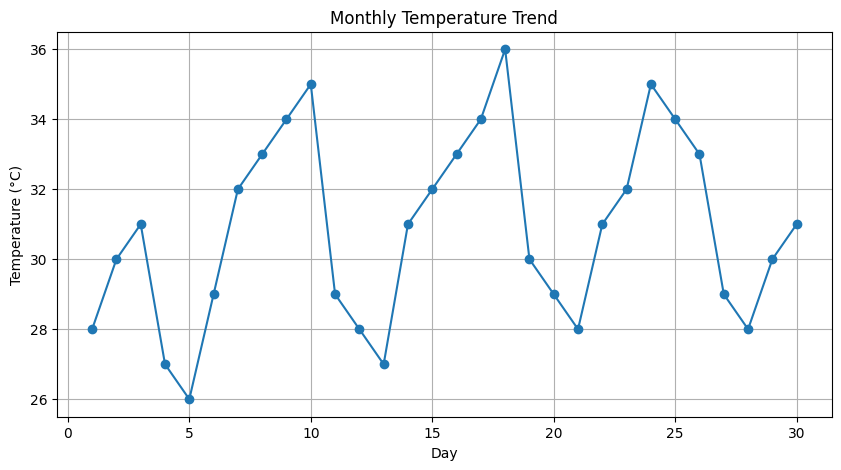

In [16]:
plt.figure(figsize=(10,5))

plt.plot(
    df["Day"],
    df["Temperature"],
    marker="o"
)

plt.title("Monthly Temperature Trend")

plt.xlabel("Day")

plt.ylabel("Temperature (°C)")

plt.grid(True)

plt.show()

Precipitation Bar Plot

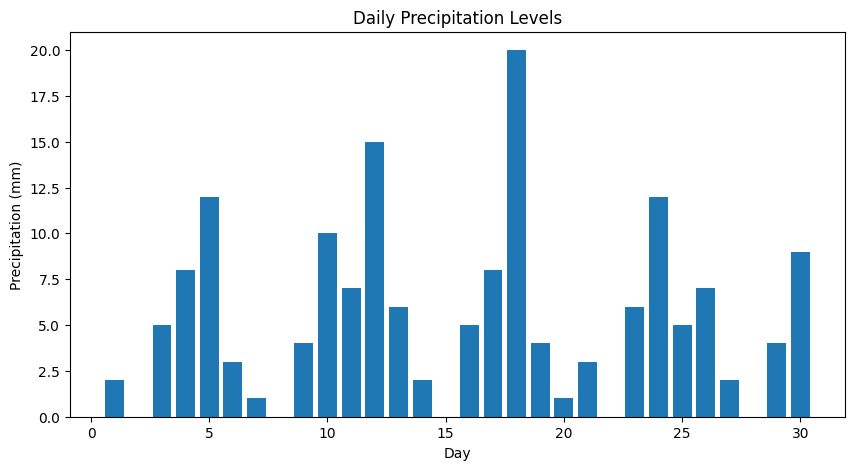

In [17]:
plt.figure(figsize=(10,5))

plt.bar(
    df["Day"],
    df["Precipitation"]
)

plt.title("Daily Precipitation Levels")

plt.xlabel("Day")

plt.ylabel("Precipitation (mm)")

plt.show()

Final Report

In [18]:
print("===== Weather Analysis Report =====")

print()

print("Average Temperature:",
      round(df["Temperature"].mean(),2))

print("Average Precipitation:",
      round(df["Precipitation"].mean(),2))

print()

print("Temperature Categories")

print(df["Temperature_Category"].value_counts())

print()

print("Rainfall Categories")

print(df["Rainfall_Category"].value_counts())

===== Weather Analysis Report =====

Average Temperature: 30.83
Average Precipitation: 5.37

Temperature Categories
Temperature_Category
Medium    17
Low        7
High       6
Name: count, dtype: int64

Rainfall Categories
Rainfall_Category
light       15
Moderate    11
Heavy        4
Name: count, dtype: int64
